In [2]:
# Libraries
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import cv2
import matplotlib.pyplot as plt
from pathlib import Path

In [3]:
# Paths
PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data" / "processed"

In [4]:
# Read CSV
images = pd.read_csv(DATA_DIR / "image_metadata.csv")
characters = pd.read_csv(DATA_DIR / "character_annotations.csv")

In [5]:
# Observe
images.head()
images.shape
images.info()
images.describe()

<class 'pandas.DataFrame'>
RangeIndex: 4500 entries, 0 to 4499
Data columns (total 53 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   split                      4500 non-null   str    
 1   track_id                   4500 non-null   str    
 2   frame_number               4500 non-null   int64  
 3   image_name                 4500 non-null   str    
 4   image_path                 4500 non-null   str    
 5   annotation_path            4500 non-null   str    
 6   image_width                4500 non-null   int64  
 7   image_height               4500 non-null   int64  
 8   camera                     4500 non-null   str    
 9   vehicle_type               4500 non-null   str    
 10  vehicle_make               4500 non-null   str    
 11  vehicle_model              4500 non-null   str    
 12  vehicle_year               4500 non-null   int64  
 13  vehicle_x                  4500 non-null   int64  
 14  veh

,frame_number,image_width,image_height,vehicle_year,vehicle_x,vehicle_y,vehicle_width,vehicle_height,vehicle_area_ratio,plate_character_count,...,plate_area_ratio,plate_aspect_ratio,relative_plate_width,relative_plate_height,image_brightness,image_contrast,image_blur_score,plate_brightness,plate_contrast,plate_blur_score
count,4500.000000,4500.0,4500.000000,4500.000000,4500.000000,4500.000000,4500.000000,4500.000000,4500.000000,4500.0,...,4500.000000,4500.000000,4500.000000,4500.000000,4500.000000,4500.000000,4500.000000,4500.000000,4500.000000,4500.000000
mean,15.500000,1920.0,1080.108444,2009.740000,695.181333,321.454444,420.621778,408.021111,0.094024,7.0,...,0.001829,2.672988,0.049527,0.033741,114.909086,66.509789,330.927259,111.715148,39.997735,1904.552039
std,8.656403,0.0,0.925195,6.569779,265.094162,140.666239,209.910731,154.950239,0.079871,0.0,...,0.001337,0.708281,0.019884,0.011512,11.380312,8.957371,190.170305,44.367200,19.151316,1775.109107
min,1.000000,1920.0,1080.000000,1976.000000,0.000000,0.000000,93.000000,173.000000,0.010898,7.0,...,0.000374,1.000000,0.016146,0.014815,75.778966,43.499834,29.677825,25.062874,5.174910,8.266993
25%,8.000000,1920.0,1080.000000,2008.000000,571.000000,259.000000,262.000000,277.000000,0.035907,7.0,...,0.000868,2.560976,0.034896,0.025000,108.517550,59.708044,196.043526,79.076680,24.787719,621.633036
50%,15.500000,1920.0,1080.000000,2011.500000,711.000000,348.000000,370.000000,377.000000,0.066812,7.0,...,0.001411,2.923077,0.045312,0.031250,114.814395,65.695403,279.695263,108.770943,36.755259,1417.015164
75%,23.000000,1920.0,1080.000000,2014.000000,832.000000,430.000000,565.000000,518.000000,0.138810,7.0,...,0.002371,3.119286,0.061979,0.041667,121.776539,72.671243,407.744165,136.308948,54.915314,2615.202117
max,30.000000,1920.0,1088.000000,2017.000000,1572.000000,530.000000,1112.000000,878.000000,0.456898,7.0,...,0.007969,4.066667,0.112500,0.075000,183.263118,94.452096,1198.040602,234.125000,87.285905,13122.572977


In [6]:
characters.head()
characters.shape
characters.info()
characters.describe()

<class 'pandas.DataFrame'>
RangeIndex: 31500 entries, 0 to 31499
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   split            31500 non-null  str    
 1   track_id         31500 non-null  str    
 2   frame_number     31500 non-null  int64  
 3   image_name       31500 non-null  str    
 4   image_path       31500 non-null  str    
 5   plate_text       31500 non-null  str    
 6   char_index       31500 non-null  int64  
 7   char_label       31500 non-null  str    
 8   char_x           31500 non-null  int64  
 9   char_y           31500 non-null  int64  
 10  char_width       31500 non-null  int64  
 11  char_height      31500 non-null  int64  
 12  char_xmax        31500 non-null  int64  
 13  char_ymax        31500 non-null  int64  
 14  char_area        31500 non-null  int64  
 15  char_relative_x  31500 non-null  float64
 16  char_relative_y  31500 non-null  float64
 17  char_box_valid   31500 

,frame_number,char_index,char_x,char_y,char_width,char_height,char_xmax,char_ymax,char_area,char_relative_x,char_relative_y
count,31500.000000,31500.000000,31500.000000,31500.000000,31500.000000,31500.000000,31500.000000,31500.000000,31500.000000,31500.000000,31500.000000
mean,15.500000,4.000000,896.800444,591.382063,11.172095,17.343175,907.972540,608.725238,214.888889,0.440865,0.356827
std,8.655579,2.000032,291.174402,128.810870,4.217785,5.815748,291.524727,132.166128,156.506137,0.256736,0.093876
min,1.000000,1.000000,17.000000,324.000000,2.000000,7.000000,31.000000,341.000000,18.000000,0.000000,0.117647
25%,8.000000,2.000000,759.000000,490.000000,8.000000,13.000000,769.000000,503.000000,104.000000,0.183908,0.304348
50%,15.500000,4.000000,890.000000,580.000000,10.000000,16.000000,899.000000,598.000000,161.000000,0.466667,0.333333
75%,23.000000,6.000000,999.000000,692.000000,14.000000,21.000000,1010.000000,708.000000,280.000000,0.676750,0.375000
max,30.000000,7.000000,1893.000000,986.000000,31.000000,39.000000,1905.000000,1010.000000,1116.000000,0.910448,0.660000


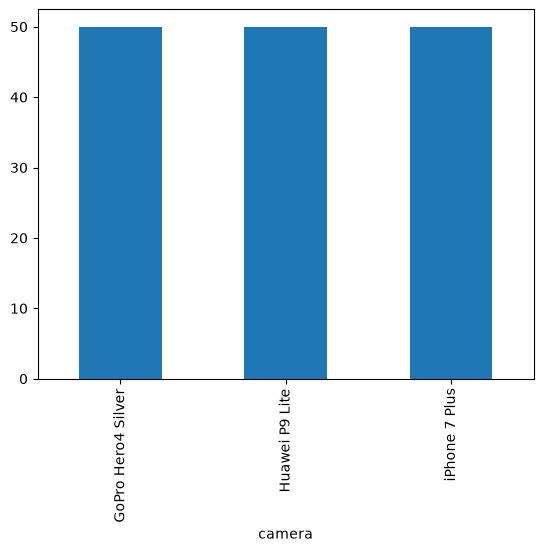

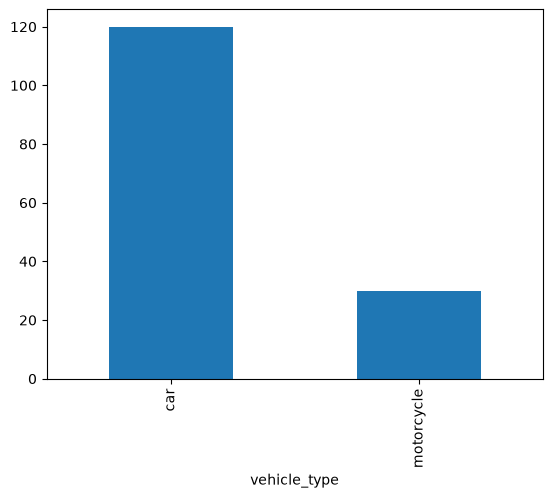

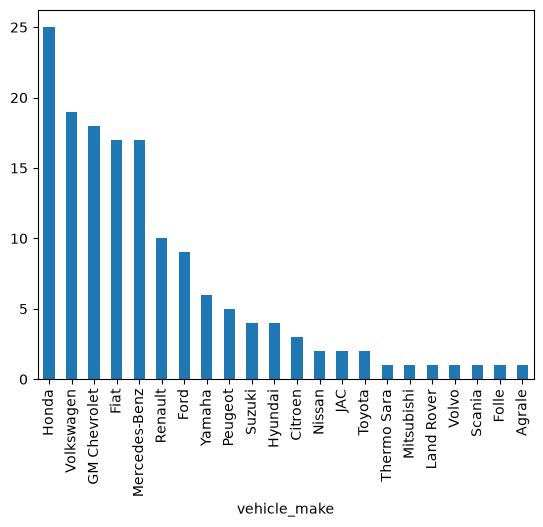

vehicle_model
CG                     12
Gol                     8
OF-1418 Neobus Mega     5
Siena                   5
Palio                   4
                       ..
Versa                   1
GSR                     1
Strada                  1
Agile                   1
Apache                  1
Name: count, Length: 81, dtype: int64

In [7]:
# Categorical Variables
# Every vehicle has 30 images per frame so must delete the 29 duplicates
tracks = images.drop_duplicates("track_id")

tracks["camera"].value_counts().plot.bar()
plt.show()

tracks["vehicle_type"].value_counts().plot.bar()
plt.show()

tracks["vehicle_make"].value_counts().plot.bar()
plt.show()

tracks["vehicle_model"].value_counts()


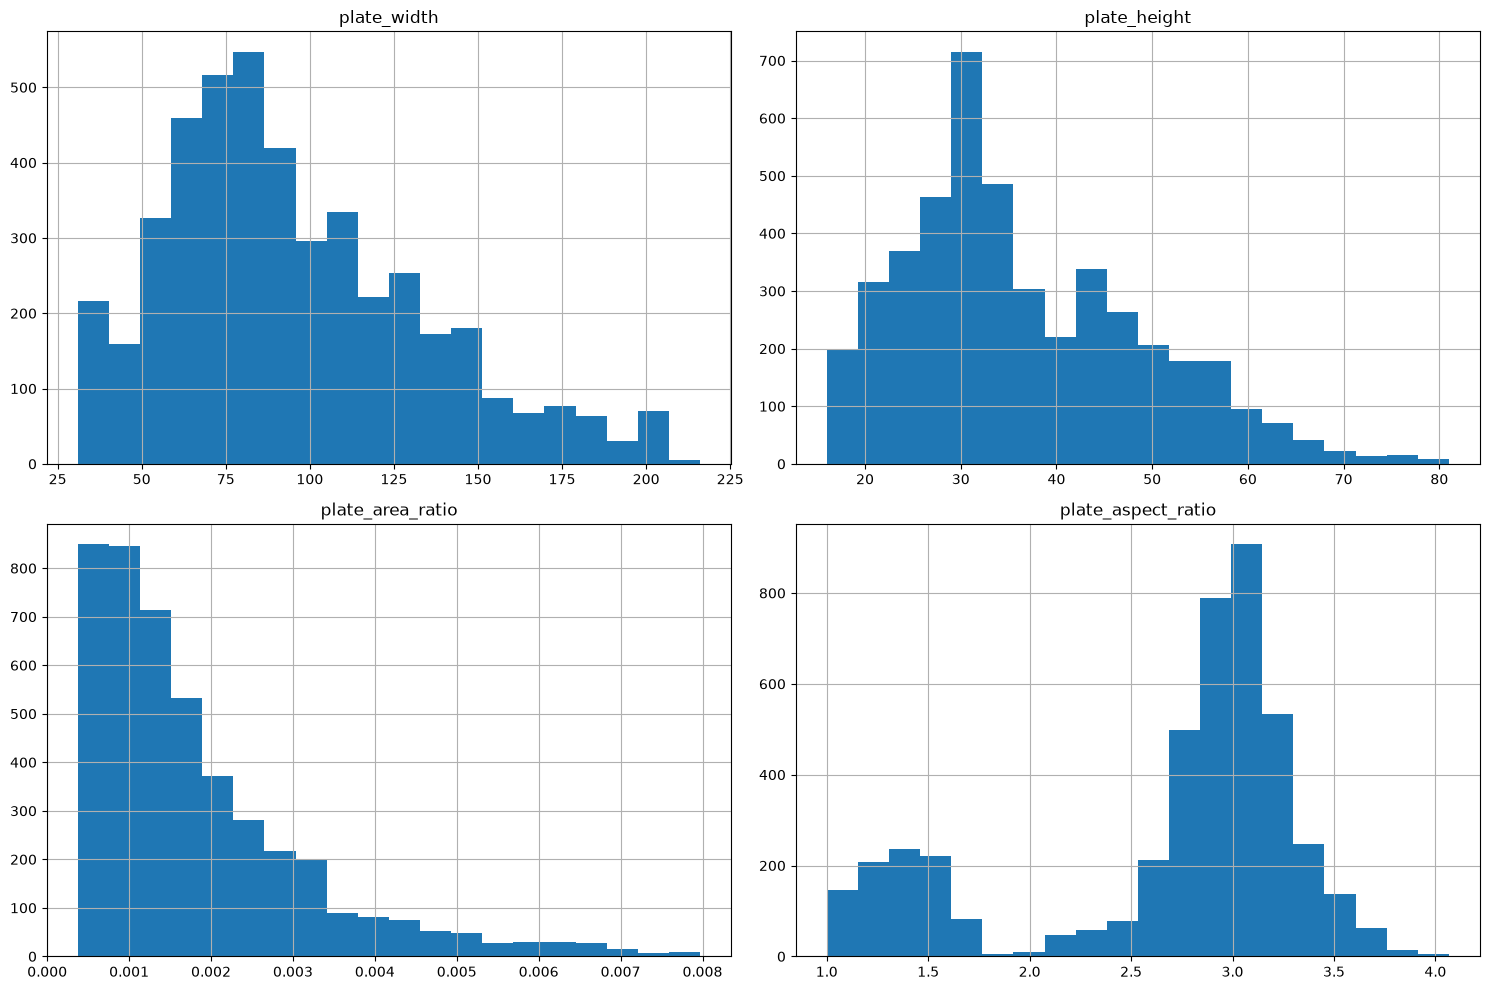

In [8]:
# Numerical Variables
plate_geo = ["plate_width", "plate_height", "plate_area_ratio", "plate_aspect_ratio"]

images[plate_geo].hist(figsize=(15,10), bins=20)
plt.tight_layout()
plt.show()

               count      mean       std       min       25%       50%  \
vehicle_type                                                             
car           3600.0  2.999439  0.292000  1.864865  2.838492  3.000000   
motorcycle     900.0  1.367185  0.188225  1.000000  1.238095  1.369968   

                   75%       max  
vehicle_type                      
car           3.170732  4.066667  
motorcycle    1.510638  1.787879  
                     count      mean       std       min       25%       50%  \
camera                                                                         
GoPro Hero4 Silver  1500.0  2.526388  0.724887  1.000000  2.304348  2.807692   
Huawei P9 Lite      1500.0  2.767017  0.706760  1.061224  2.750000  3.025000   
iPhone 7 Plus       1500.0  2.725559  0.669004  1.210526  2.690801  2.944444   

                         75%       max  
camera                                  
GoPro Hero4 Silver  3.000000  3.888889  
Huawei P9 Lite      3.200000  3.916667 

<Axes: title={'center': 'plate_aspect_ratio'}, xlabel='camera'>

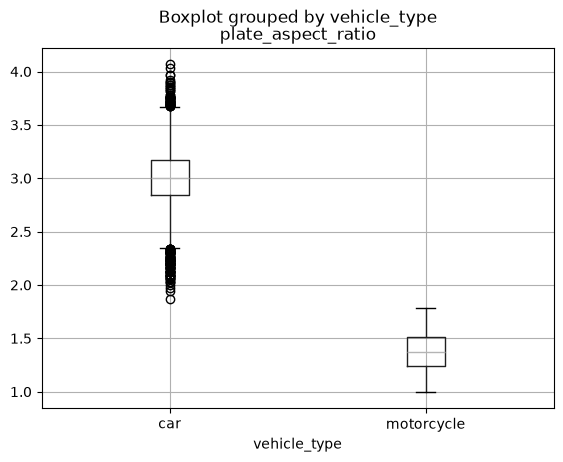

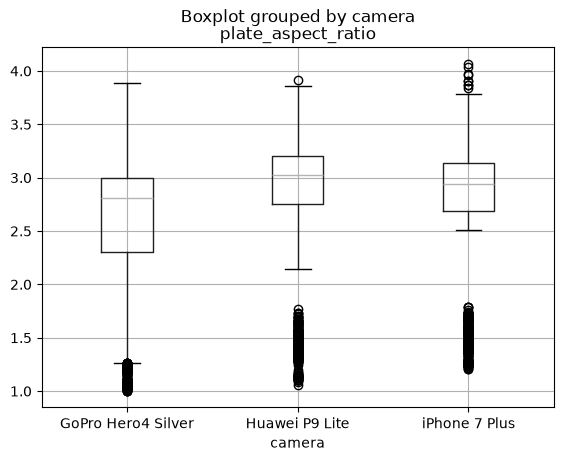

In [9]:
# Comparison (Numerical and Categorical)
print(images.groupby("vehicle_type")["plate_aspect_ratio"].describe())
images.boxplot(column="plate_aspect_ratio", by="vehicle_type")
# Cars have higher aspect ratios than motercycles

print(images.groupby("camera")["plate_aspect_ratio"].describe())
images.boxplot(column="plate_aspect_ratio", by="camera")
# Different cameras have simiilar aspect ratios


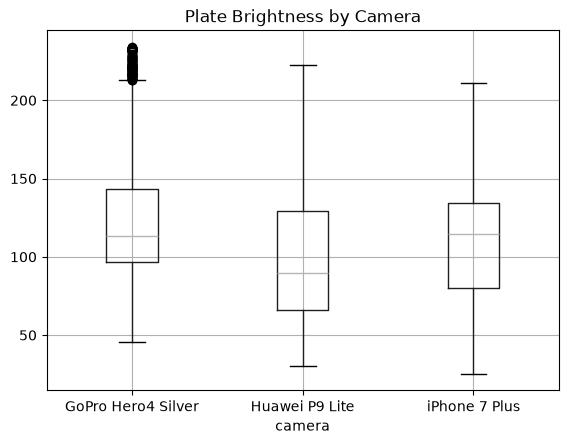

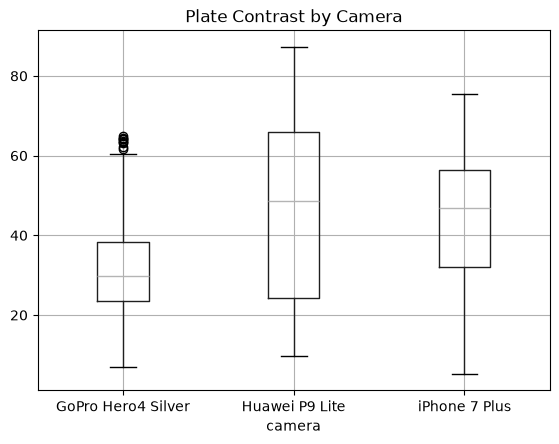

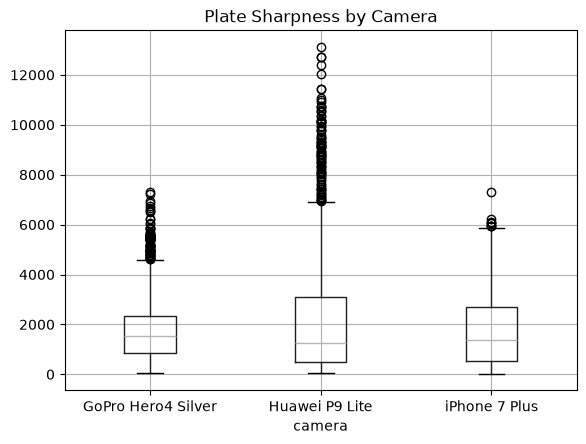

In [ ]:
# Cameras
# Do different cameras produce different quality images
images.groupby("camera")["plate_brightness"].describe()

images.boxplot(column="plate_brightness", by="camera")

plt.title("Plate Brightness by Camera")
plt.suptitle("")
plt.show()
# Huawei P9 Lite has lowest median brightness while other two have similar higher

images.groupby("camera")["plate_contrast"].describe()

images.boxplot(column="plate_contrast", by="camera")

plt.title("Plate Contrast by Camera")
plt.suptitle("")
plt.show()
# GoPro Hero4 Silver has lowest median contrast while other have similar higher

images.groupby("camera")["plate_blur_score"].describe()

images.boxplot(column="plate_blur_score",by="camera")

plt.title("Plate Sharpness by Camera")
plt.suptitle("")
plt.show()
# Huawei P9 Lite has highest sharpness while other two have similar lower

         split   track_id  frame_number         image_name  \
4058   testing  track0136             9  track0136[09].png   
4060   testing  track0136            11  track0136[11].png   
4054   testing  track0136             5  track0136[05].png   
4062   testing  track0136            13  track0136[13].png   
918   training  track0031            19  track0031[19].png   

                                             image_path  \
4058  data/raw/ufpr_alpr/testing/track0136/track0136...   
4060  data/raw/ufpr_alpr/testing/track0136/track0136...   
4054  data/raw/ufpr_alpr/testing/track0136/track0136...   
4062  data/raw/ufpr_alpr/testing/track0136/track0136...   
918   data/raw/ufpr_alpr/training/track0031/track003...   

                                        annotation_path  image_width  \
4058  data/raw/ufpr_alpr/testing/track0136/track0136...         1920   
4060  data/raw/ufpr_alpr/testing/track0136/track0136...         1920   
4054  data/raw/ufpr_alpr/testing/track0136/track0136... 

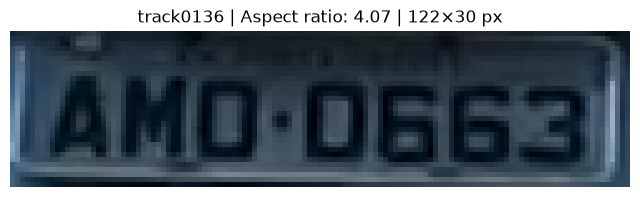

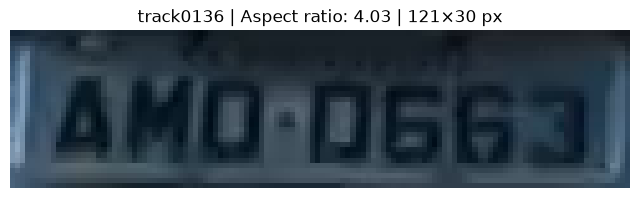

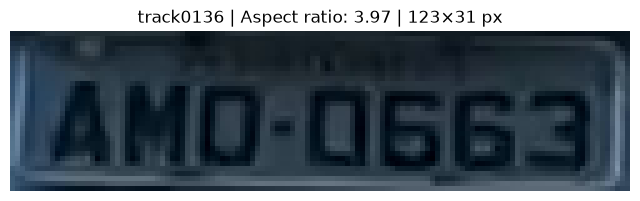

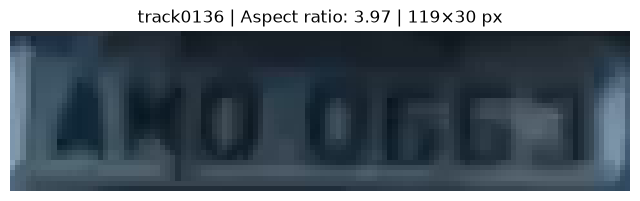

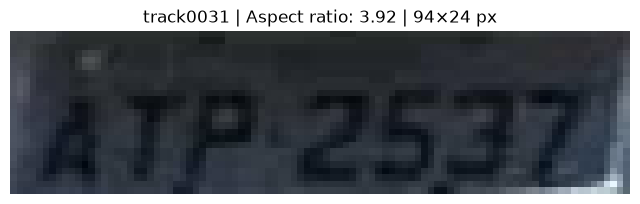

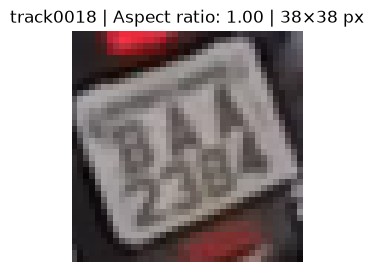

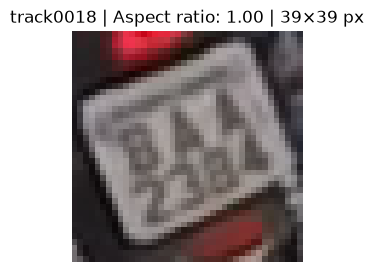

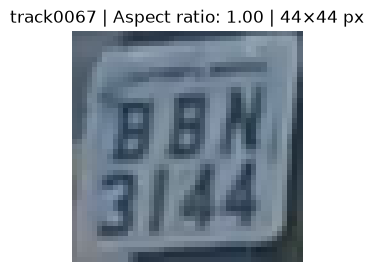

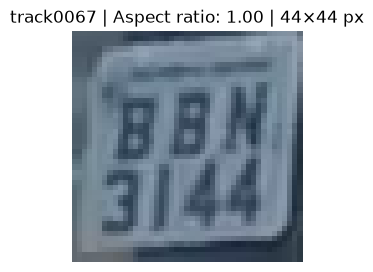

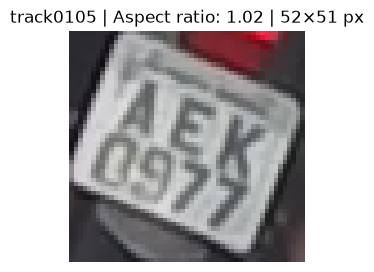

In [11]:
# Outliers
# A lot of outliers in the box plots
print(images.nlargest(5, "plate_aspect_ratio"))
print(images.nsmallest(5, "plate_aspect_ratio"))

# Some outliers come from the same track
PROJECT_ROOT = Path.cwd().parent

def show_plate(row):
    """Display the plate crop for one metadata row."""
    image_path = PROJECT_ROOT / row["image_path"]
    image = cv2.imread(str(image_path))

    if image is None:
        raise FileNotFoundError(f"Could not read image: {image_path}")

    xmin = int(row["plate_xmin"])
    ymin = int(row["plate_ymin"])
    xmax = int(row["plate_xmax"])
    ymax = int(row["plate_ymax"])

    plate_crop = image[ymin:ymax + 1, xmin:xmax + 1]

    if plate_crop.size == 0:
        raise ValueError(f"Empty plate crop for: {image_path}")

    plate_crop = cv2.cvtColor(plate_crop, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(8, 3))
    plt.imshow(plate_crop)
    plt.title(
        f'{row["track_id"]} | '
        f'Aspect ratio: {row["plate_aspect_ratio"]:.2f} | '
        f'{row["plate_width"]}×{row["plate_height"]} px'
    )
    plt.axis("off")
    plt.show()

high_aspect_outliers = images.nlargest(5, "plate_aspect_ratio")

for _, row in high_aspect_outliers.iterrows():
    show_plate(row)

low_aspect_outliers = images.nsmallest(5,"plate_aspect_ratio")

for _, row in low_aspect_outliers.iterrows():
    show_plate(row)

# The largest and smallest aspect ratio are not errors but simply wider or shorter plates.

<Axes: >

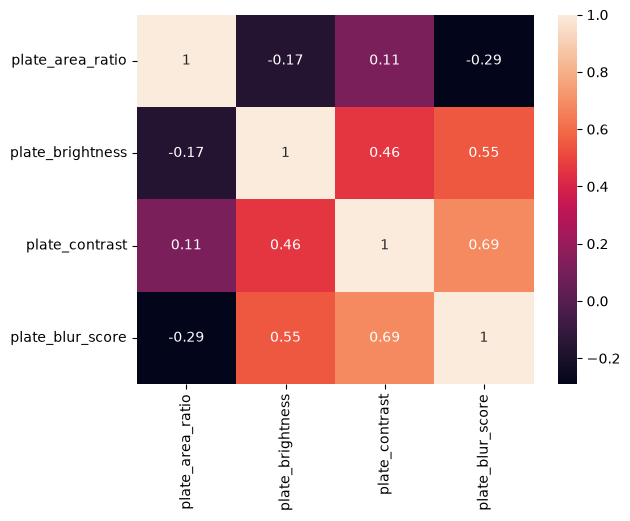

In [12]:
# Correlations
# plate_blur_score measures sharpness, higher means sharper
corr = images[["plate_area_ratio", "plate_brightness", "plate_contrast", "plate_blur_score"]].corr()
sns.heatmap(corr, annot=True)

# 0.69: plates with stronger edge contrast tend to produce higher sharpness measurements (obvious)
# 0.46: brighter plates have higher contrast (obvious)
# -0.29: larger plates are less sharp (?)


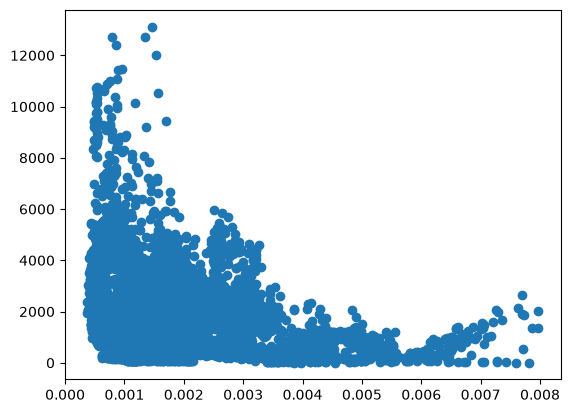

In [13]:
plt.scatter(images['plate_area_ratio'], images['plate_blur_score'])
plt.show()

# Conclude smaller plates are less sharp and higher sharpness variability while larger plates are consistent and sharper

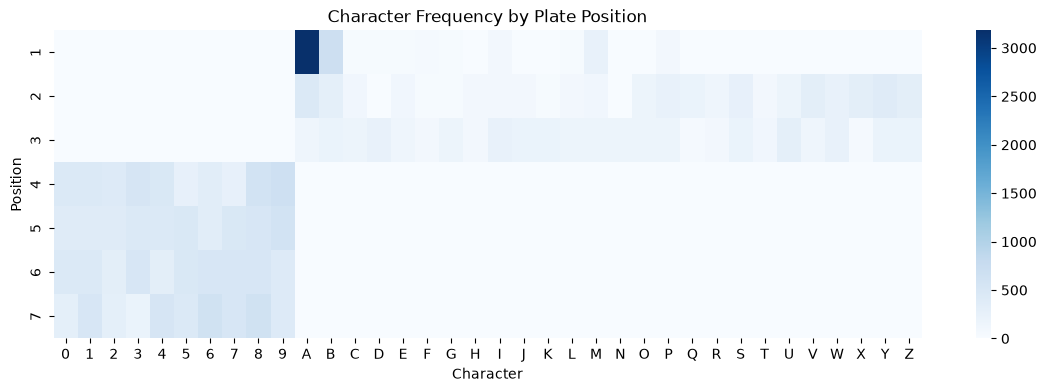

In [14]:
# Characters
characters["char_label"].value_counts()
ct = pd.crosstab(characters["char_index"], characters["char_label"])

plt.figure(figsize=(14, 4))
sns.heatmap(ct, cmap="Blues")
plt.title("Character Frequency by Plate Position")
plt.xlabel("Character")
plt.ylabel("Position")
plt.show()

# All license plate follow first 3 positions are letters and last four positions are digits